# Encoding and Comparing Molecules
Import and draw molecules
Calculate molecular descriptors
1D molecular descriptors: Molecular weight
2D molecular descriptors: MACCS fingerprint
2D molecular descriptors: Morgan fingerprint
Calculate molecular similarity
MACCS fingerprints: Tanimoto and Dice similarity
Morgan fingerprints: Tanimoto and Dice similarity
Virtual screening using similarity search
Compare query molecule to all molecules in the data set
Distribution of similarity values
Visualize most similar molecules
Generate enrichment plots
Calculate enrichment factors

### Molecular fingerprints¶
**Substructure-based fingerprints¶**
Molecular fingerprints are a computational representation of molecules that encode chemical and molecular features in the form of bitstrings, bitvectors or arrays. Each bit corresponds to a predefined molecular feature or environment, where “1” represents the presence and “0” the absence of a feature. Note that some implementations are count-based. Thus, they count how often a specific feature is present.

MACCS keys and Morgan fingerprint are commonly used 2D fingerprints. Rdkit also offers multiple alternate fingerprints.

**MACCS fingerprints¶**
Molecular ACCess System (MACCS) fingerprints, also termed MACCS structural keys, consist of 166 predefined structural fragments. Each position queries the presence or absence of one particular structural fragment or key. The individual keys were empirically defined by medicinal chemists and are simple to use and interpret (rdkit documentation on MACCS keys).

**Morgan fingerprints and circular fingerprints¶**
Based on the Morgan algorithm. The bits correspond to the circular environments of each atom in a molecule. The number of neighboring bonds and atoms to consider is set by the radius. Also the length of the bit string can be defined, a longer bit string will be modded to the desired length. Therefore, the Morgan fingerprint is not limited to a certain number of bits. More about the Morgan fingerprint can be found in the rdkit documentation. Extended connectivity fingerprints (ECFP) are also commonly used fingerprints that are derived using a variant of the Morgan algorithm, see J. Chem. Inf. Model. (2010), 50,742-754 for further information.

### Molecular similarity measures¶
Once descriptors/fingerprints are calculated they can be compared to assess the similarity between two molecules. Molecular similarity can be quantified with a number of different similarity coefficients. Two common similarity measures are the Tanimoto and Dice index:


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem, DataStructs
from rdkit.Chem import PandasTools, Draw, Descriptors, MACCSkeys, rdFingerprintGenerator

In [2]:
DATA_DIR = Path("/Users/duncanfreeman/dev/bioinfo/data")

In [3]:
# Molecules in SMILES format
molecule_smiles = [
    "CC1C2C(C3C(C(=O)C(=C(C3(C(=O)C2=C(C4=C1C=CC=C4O)O)O)O)C(=O)N)N(C)C)O",
    "CC1(C(N2C(S1)C(C2=O)NC(=O)C(C3=CC=C(C=C3)O)N)C(=O)O)C",
    "C1=COC(=C1)CNC2=CC(=C(C=C2C(=O)O)S(=O)(=O)N)Cl",
    "CCCCCCCCCCCC(=O)OCCOC(=O)CCCCCCCCCCC",
    "C1NC2=CC(=C(C=C2S(=O)(=O)N1)S(=O)(=O)N)Cl",
    "CC1=C(C(CCC1)(C)C)C=CC(=CC=CC(=CC(=O)O)C)C",
    "CC1(C2CC3C(C(=O)C(=C(C3(C(=O)C2=C(C4=C1C=CC=C4O)O)O)O)C(=O)N)N(C)C)O",
    "CC1C(CC(=O)C2=C1C=CC=C2O)C(=O)O",
]

# List of molecule names
molecule_names = [
    "Doxycycline",
    "Amoxicilline",
    "Furosemide",
    "Glycol dilaurate",
    "Hydrochlorothiazide",
    "Isotretinoin",
    "Tetracycline",
    "Hemi-cycline D",
]

,smiles,name,ROMol
0,CC1C2C(C3C(C(=O)C(=C(C3(C(=O)C2=C(C4=C1C=CC=C4...,Doxycycline,
1,CC1(C(N2C(S1)C(C2=O)NC(=O)C(C3=CC=C(C=C3)O)N)C...,Amoxicilline,

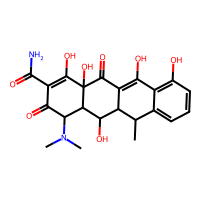
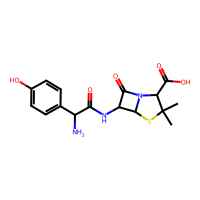

In [4]:
molecules = pd.DataFrame({"smiles": molecule_smiles, "name": molecule_names})
PandasTools.AddMoleculeColumnToFrame(molecules, smilesCol="smiles")
PandasTools.RenderImagesInAllDataFrames(True)
# Show first 2 molecules
molecules.head(2)

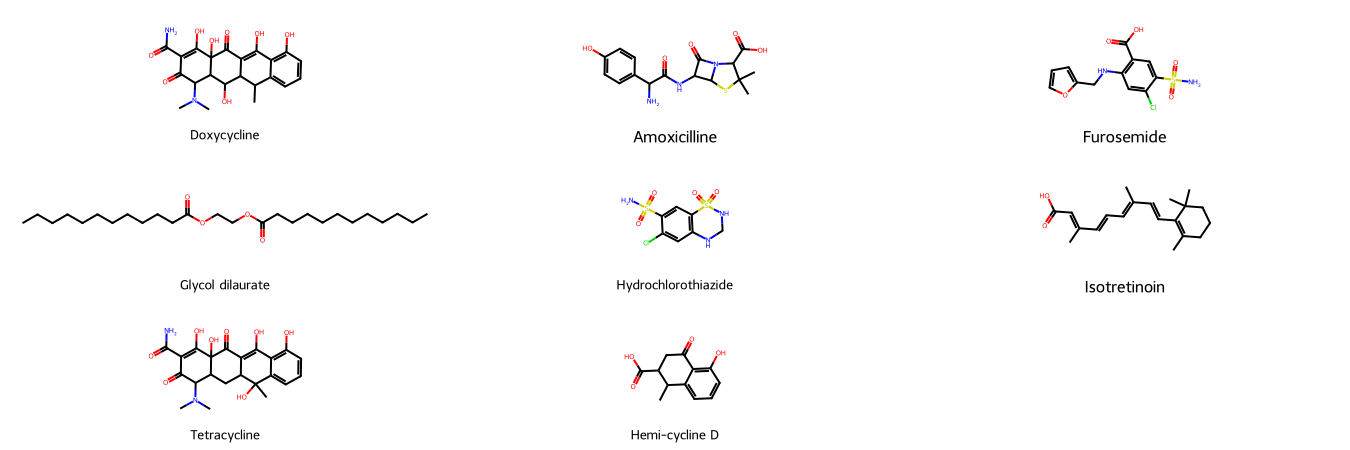

In [5]:
Draw.MolsToGridImage(
    molecules["ROMol"].to_list(),
    molsPerRow=3,
    subImgSize=(450, 150),
    legends=molecules["name"].to_list(),
)

### Calculate molecular descriptors
Generate 1D and 2D molecular descriptors to compare our molecules. 
For 2D descriptors, different types of fingerprints are generated to be used later for the calculation of the molecular similarity.

**1D molecular descriptors: Molecular weight**
Calculate the molecular weight of our example structures...

In [6]:
# Apply the rdkit.chem Descriptors MolWt function to all ROMol objects in the DataFrame
molecules["molecule_weight"] = molecules.ROMol.apply(Descriptors.MolWt)
# Sort molecules by molecular weight
molecules.sort_values(["molecule_weight"], ascending=False, inplace=True)

Draw molecular structures with similar molecular weight for visual comparison: 
Is the molecular weight a feasible descriptor for molecule similarity?

In [7]:
# Show only molecule names and molecular weights
molecules[["smiles", "name", "molecule_weight"]]

,smiles,name,molecule_weight
0,CC1C2C(C3C(C(=O)C(=C(C3(C(=O)C2=C(C4=C1C=CC=C4...,Doxycycline,444.440
6,CC1(C2CC3C(C(=O)C(=C(C3(C(=O)C2=C(C4=C1C=CC=C4...,Tetracycline,444.440
3,CCCCCCCCCCCC(=O)OCCOC(=O)CCCCCCCCCCC,Glycol dilaurate,426.682
1,CC1(C(N2C(S1)C(C2=O)NC(=O)C(C3=CC=C(C=C3)O)N)C...,Amoxicilline,365.411
2,C1=COC(=C1)CNC2=CC(=C(C=C2C(=O)O)S(=O)(=O)N)Cl,Furosemide,330.749
5,CC1=C(C(CCC1)(C)C)C=CC(=CC=CC(=CC(=O)O)C)C,Isotretinoin,300.442
4,C1NC2=CC(=C(C=C2S(=O)(=O)N1)S(=O)(=O)N)Cl,Hydrochlorothiazide,297.745
7,CC1C(CC(=O)C2=C1C=CC=C2O)C(=O)O,Hemi-cycline D,220.224


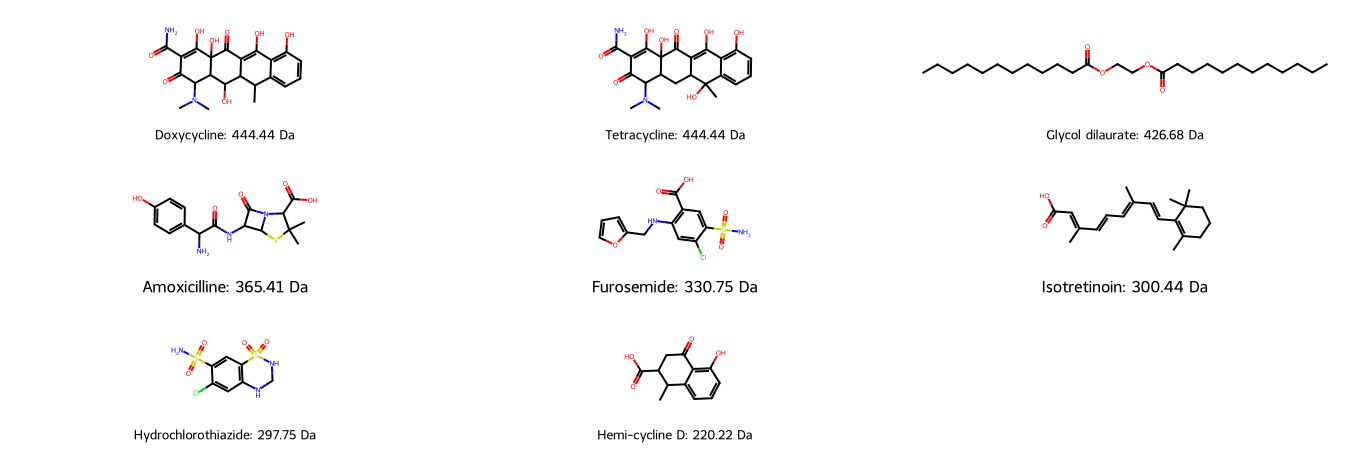

In [8]:
# Draw mols with their molwt
Draw.MolsToGridImage(
    molecules["ROMol"],
    legends=[
        f"{molecule['name']}: {molecule['molecule_weight']:.2f} Da"
        for index, molecule in molecules.iterrows()
    ],
    subImgSize=(450, 150),
    molsPerRow=3,
)

> NOTE: Molecules of similar weight *can* have similar structure, but they can also have a similar number of atoms in completely different arrangements.
For a more detailed analysis, look at 2D mol descriptors:

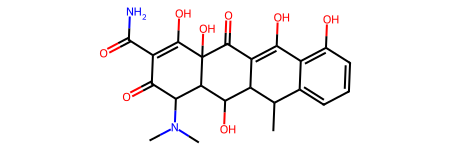

In [9]:
molecule = molecules["ROMol"][0]
molecule

In [13]:
import numpy as np
# Generate MACCS keys for the first molecule
maccs_keys_fp = MACCSkeys.GenMACCSKeys(molecule)
# Transform the MACCS keys into a bitstring representation
# NBVAL_CHECK_OUTPUT
maccs_keys_fp.ToBitString()

'00000000000000000000000000100000000000000000000000100110000000000010000010101000000011100100110101010100010000101100010000100001000101001001111111101111101011111111110'

In [14]:
molecules["maccs"] = molecules.ROMol.apply(MACCSkeys.GenMACCSKeys)

2D molecular descriptors: Morgan fingerprint
Morgan fingerprints can be calculated as int or bit vector. We specify a radius of 2 and a vector of length 2048.

Generate the Morgan fingerprint as int vector with example molecule:

In [15]:
morgan_fpg = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
circular_int_fp = morgan_fpg.GetCountFingerprint(molecule)
print(f"Print non-zero elements:\n{circular_int_fp.GetNonzeroElements()}")

Print non-zero elements:
{45: 1, 118: 1, 140: 1, 163: 1, 276: 1, 303: 1, 309: 1, 314: 2, 371: 1, 438: 1, 525: 1, 557: 1, 650: 3, 673: 1, 699: 1, 807: 6, 824: 1, 829: 1, 881: 1, 1009: 1, 1019: 5, 1027: 1, 1039: 1, 1057: 3, 1060: 1, 1061: 1, 1070: 1, 1082: 1, 1088: 1, 1119: 1, 1154: 1, 1163: 2, 1171: 1, 1257: 1, 1296: 1, 1309: 1, 1341: 1, 1380: 9, 1389: 1, 1457: 1, 1471: 1, 1487: 1, 1582: 1, 1602: 3, 1607: 1, 1630: 1, 1747: 1, 1750: 2, 1831: 1, 1833: 1, 1857: 1, 1873: 3, 1917: 1, 1932: 1, 2000: 1, 2029: 1}


In [16]:
# Morgan fingerprint as bit vector:
# Note that the function takes a list as input parameter
# (even if we only want to pass one molecule)
circular_bit_fp = morgan_fpg.GetFingerprint(molecule)
print(f"Print top 400 fingerprint bits:\n{circular_bit_fp.ToBitString()[:400]}")

Print top 400 fingerprint bits:
0000000000000000000000000000000000000000000001000000000000000000000000000000000000000000000000000000000000000000000000100000000000000000000010000000000000000000000100000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000001000000000000000000000000001000001000010000000000000000000000000000000000000000000000000000000010000000000000000000000000000


In [17]:
# Apply Morgan fingerprint as bit vectors to df:
molecules["morgan"] = molecules["ROMol"].map(morgan_fpg.GetFingerprint)

### Calculate molecular similarity
Example: apply two similarity measures, (Tanimoto and Dice) to the two fingerprint types (MACCS and Morgan fingerprints).

Example molecule pair: Compare two MACCS fingerprints with the Tanimoto similarity.

In [18]:
# Example molecules
molecule1 = molecules["ROMol"][0]
molecule2 = molecules["ROMol"][1]

# Example MACCS fingerprints
maccs_fp1 = MACCSkeys.GenMACCSKeys(molecule1)
maccs_fp2 = MACCSkeys.GenMACCSKeys(molecule2)

In [19]:
# Calculate the Tanimoto similarity between the same molecule MACCS fingerprints
DataStructs.TanimotoSimilarity(maccs_fp1, maccs_fp1)

1.0

Compare a query molecule with our molecule list. Use **BulkTanimotoSimilarity** and **BulkDiceSimilarity** from rdkit that calculate the similarity of a query fingerprint with a list of fingerprints. 
Investigate all combinations of MACCS/Morgan fingerprint comparisons based on the Tanimoto/Dice similarity measure.

,smiles,name,ROMol,molecule_weight,maccs,morgan
0,CC1C2C(C3C(C(=O)C(=C(C3(C(=O)C2=C(C4=C1C=CC=C4...,Doxycycline,,444.44,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."

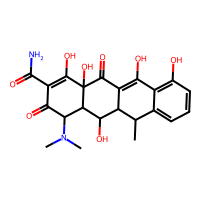

In [21]:
molecules.head(1)

In [22]:
# Define molecule query and list
molecule_query = molecules["maccs"][0]
# Get the list of MACCS fingerprints from the DataFrame as a list to compare against the query molecule
molecule_list = molecules["maccs"].to_list()

# Calculate similarty values between query and list elements
molecules["tanimoto_maccs_similarity"] = DataStructs.BulkTanimotoSimilarity(molecule_query, molecule_list)
molecules["dice_maccs_similarity"] = DataStructs.BulkDiceSimilarity(molecule_query, molecule_list)

In [23]:
# Sort DataFrame by Tanimoto similarity of the MACCS fingerprints (name and similarity columns only)
preview_df = molecules.sort_values(["tanimoto_maccs_similarity"], ascending=False).reset_index()
preview_df[["name", "tanimoto_maccs_similarity", "dice_maccs_similarity"]]

,name,tanimoto_maccs_similarity,dice_maccs_similarity
0,Doxycycline,1.000000,1.000000
1,Tetracycline,0.928571,0.962963
2,Amoxicilline,0.590909,0.742857
3,Hemi-cycline D,0.403509,0.575000
4,Furosemide,0.321839,0.486957
5,Hydrochlorothiazide,0.306818,0.469565
6,Isotretinoin,0.288136,0.447368
7,Glycol dilaurate,0.149254,0.259740


Note: Tanimoto and Dice similarity measures by definition result in the same ranking of molecules, with higher values for the Dice similarity.

In [24]:
def draw_ranked_molecules(molecules: pd.DataFrame, sort_by_column: str) -> Draw.MolsToGridImage:
    """
    Draw molecules sorted by a given column.

    Parameters
    ----------
    molecules : pandas.DataFrame
        Molecules (with "ROMol" and "name" columns and a column to sort by.
    sort_by_column : str
        Name of the column used to sort the molecules by.

    Returns
    -------
    Draw.MolsToGridImage
        2D visualization of sorted molecules.
    """

    molecules_sorted = molecules.sort_values([sort_by_column], ascending=False).reset_index()
    return Draw.MolsToGridImage(
        molecules_sorted["ROMol"],
        legends=[
            f"#{index+1} {molecule['name']}, similarity={molecule[sort_by_column]:.2f}"
            for index, molecule in molecules_sorted.iterrows()
        ],
        molsPerRow=3,
        subImgSize=(450, 150),
    )

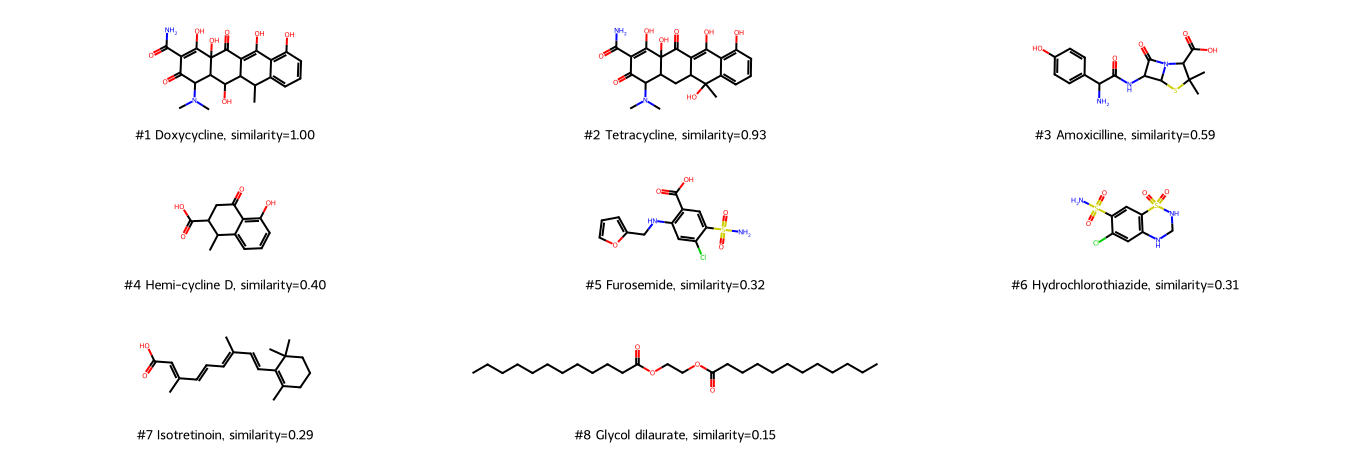

In [25]:
draw_ranked_molecules(molecules, "tanimoto_maccs_similarity")

With MACCS fingerprints, Tetracycline is the most similar molecule, followed by Amoxicilline. 
In contrast to the 1D descriptor (molecular weight), the linear molecule Glycol dilaurate is recognized as dissimilar (last rank).

### Morgan fingerprints: Tanimoto similarity and Dice similarity
Add the Tanimoto and Dice similarities between the Morgan fingerprints to the DataFrame.

In [26]:
# Define molecule query and list
molecule_query = molecules["morgan"][0]
molecule_list = molecules["morgan"].to_list()
# Calculate similarty values between query and list elements
molecules["tanimoto_morgan_similarity"] = DataStructs.BulkTanimotoSimilarity(molecule_query, molecule_list)
molecules["dice_morgan_similarity"] = DataStructs.BulkDiceSimilarity(molecule_query, molecule_list)

In [27]:
preview_df = molecules.sort_values(["tanimoto_morgan_similarity"], ascending=False).reset_index()
preview_df[["name", "tanimoto_morgan_similarity", "dice_morgan_similarity", "tanimoto_maccs_similarity", "dice_maccs_similarity"]]

,name,tanimoto_morgan_similarity,dice_morgan_similarity,tanimoto_maccs_similarity,dice_maccs_similarity
0,Doxycycline,1.000000,1.000000,1.000000,1.000000
1,Tetracycline,0.534247,0.696429,0.928571,0.962963
2,Hemi-cycline D,0.308824,0.471910,0.403509,0.575000
3,Amoxicilline,0.144444,0.252427,0.590909,0.742857
4,Furosemide,0.098901,0.180000,0.321839,0.486957
5,Isotretinoin,0.067416,0.126316,0.288136,0.447368
6,Hydrochlorothiazide,0.058824,0.111111,0.306818,0.469565
7,Glycol dilaurate,0.054795,0.103896,0.149254,0.259740


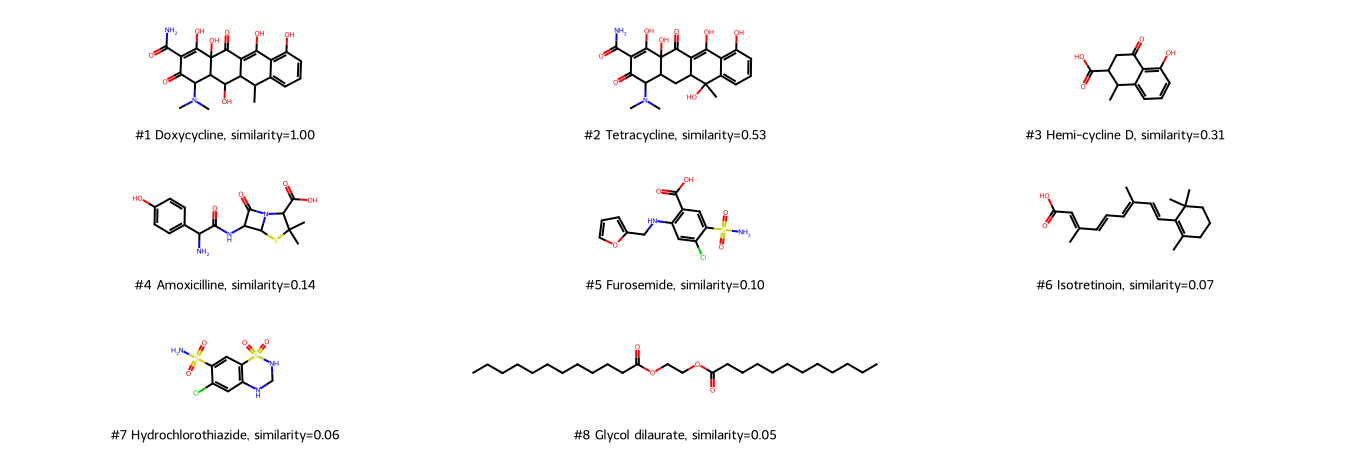

In [28]:
# Ranked molecules by Tanimoto similarity of the Morgan fingerprints
draw_ranked_molecules(molecules, "tanimoto_morgan_similarity")

Compare the Tanimoto similarities based on MACCS and Morgan fingerprints --> plot the Tanimoto similarities based on Morgen fingerprints vs. the Tanimoto simlarities based on MACCS fingerprints.

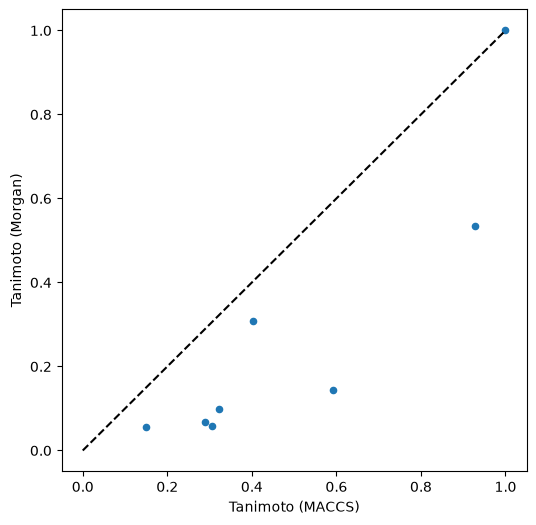

In [29]:
fig, ax = plt.subplots(figsize=(6, 6))
molecules.plot("tanimoto_maccs_similarity", "tanimoto_morgan_similarity", kind="scatter", ax=ax)
ax.plot([0, 1], [0, 1], "k--")
ax.set_xlabel("Tanimoto (MACCS)")
ax.set_ylabel("Tanimoto (Morgan)")
fig;

Different fingerprints (here: MACCS and Morgan fingerprints) results in different similarity values (here: Tanimoto similarity), and thus potentially also in different rankings of molecule similarity as shown here.

Morgan fingerprints also recognize Tetracycline as the most similar molecule to Doxycycline (but with a lower score), and Clycol dilaurate as most dissimilar. However, ranked second is Hemi-cycline D, a structural part of cyclines - possibly because of the atom environment-based algorithm of Morgan fingerprints (whereas MACCS fingerprints rather ask for the occurrence of certain properties).

Virtual screening using similarity search¶
Now that we have learned how to calculate fingerprints and the similarity between them, we can apply this knowledge to a similarity search of a query molecule against a full data set of molecules.

We use the known EGFR inhibitor Gefitinib as query and search for similar molecules in our data set of molecules tested on EGFR, which we collected from the ChEMBL database in Talktorial T001 and filtered by Lipinski’s rule of five in Talktorial T002.

Compare query molecule to all molecules in the data set¶
We import molecules from a csv file containing the filtered EGFR-tested molecules from the ChEMBL database as provided by Talktorial T002. Given one query molecule (here **Gefitinib**), we screen that data set for similar molecules.

In [30]:
egfr_df = pd.read_csv(
    DATA_DIR / "EGFR_molecules_ro5_fulfilled.csv",
    usecols=["molecule_chembl_id", "smiles", "pIC50"],
)
print(f"Number of molecules in dataset: {len(egfr_df)}")
egfr_df.head(2)

Number of molecules in dataset: 4661


,molecule_chembl_id,smiles,pIC50
0,CHEMBL63786,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879
1,CHEMBL35820,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849


**Query:** For Gefitinib, generate the ROMol object from the query the molecule's SMILES.

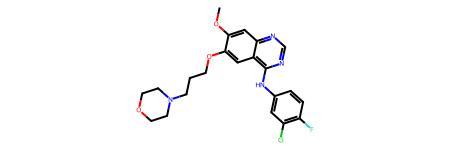

In [31]:
query = Chem.MolFromSmiles("COC1=C(OCCCN2CCOCC2)C=C2C(NC3=CC(Cl)=C(F)C=C3)=NC=NC2=C1")
query

In [33]:
# Generate MACCS and Morgan fingerprints for the query molecule.
maccs_fp_query = MACCSkeys.GenMACCSKeys(query)
circular_fp_query = morgan_fpg.GetCountFingerprint(query)

# Generate MACCS and Morgan fingerprints for all molecules in egfr_df dataset.
PandasTools.AddMoleculeColumnToFrame(egfr_df, "smiles")
circular_fp_list = egfr_df["ROMol"].apply(morgan_fpg.GetCountFingerprint).tolist()
maccs_fp_list = egfr_df["ROMol"].apply(MACCSkeys.GenMACCSKeys).tolist()

Calculate the Tanimoto and Dice similarity between the query molecule (Gefitinib) and all molecules in dataset (using MACCS and Morgan fingerprints).

In [35]:
# Tanimoto similarity calculations for the query molecule against all molecules in the dataset.
egfr_df["tanimoto_maccs"] = DataStructs.BulkTanimotoSimilarity(
    maccs_fp_query, maccs_fp_list
)
egfr_df["tanimoto_morgan"] = DataStructs.BulkTanimotoSimilarity(
    circular_fp_query, circular_fp_list
)

# Dice similarity calculations for the query molecule against all molecules in the dataset.
egfr_df["dice_maccs"] = DataStructs.BulkDiceSimilarity(maccs_fp_query, maccs_fp_list)
egfr_df["dice_morgan"] = DataStructs.BulkDiceSimilarity(
    circular_fp_query, circular_fp_list
)

In [36]:
egfr_df[
    ["smiles", "tanimoto_maccs", "tanimoto_morgan", "dice_maccs", "dice_morgan"]
].head(3)

,smiles,tanimoto_maccs,tanimoto_morgan,dice_maccs,dice_morgan
0,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,0.409836,0.324786,0.581395,0.490323
1,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,0.666667,0.445455,0.800000,0.616352
2,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,0.484375,0.327434,0.652632,0.493333


,molecule_chembl_id,smiles,pIC50,ROMol,tanimoto_maccs,tanimoto_morgan,dice_maccs,dice_morgan
0,CHEMBL63786,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,,0.409836,0.324786,0.581395,0.490323
1,CHEMBL35820,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849,,0.666667,0.445455,0.800000,0.616352
2,CHEMBL53711,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849,,0.484375,0.327434,0.652632,0.493333

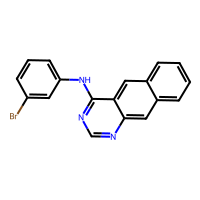
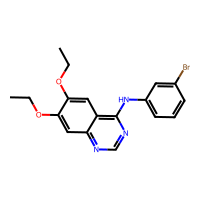
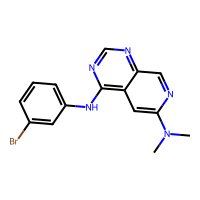

In [37]:
egfr_df.head(3)

### Distribution of similarity values
When compared for the same fingerprint measure (e.g. MACCS), Tanimoto similarity values are lower than Dice similarity values. 
When comparing two different fingerprints (e.g. MACCS and Morgan), the similarity measure values (e.g. Tanimoto similarity) vary.

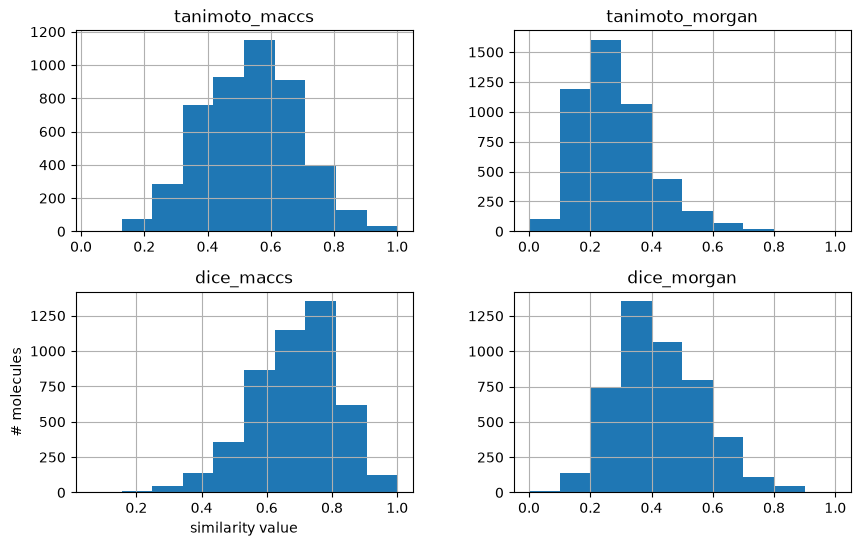

In [38]:
# Analyze the distributions by plotting histograms.

# Tanimoto similarity of MACCS fingerprints.
fig, axes = plt.subplots(figsize=(10, 6), nrows=2, ncols=2)
egfr_df.hist(["tanimoto_maccs"], ax=axes[0, 0])
egfr_df.hist(["tanimoto_morgan"], ax=axes[0, 1])
egfr_df.hist(["dice_maccs"], ax=axes[1, 0])
egfr_df.hist(["dice_morgan"], ax=axes[1, 1])
axes[1, 0].set_xlabel("similarity value")
axes[1, 0].set_ylabel("# molecules")
fig;

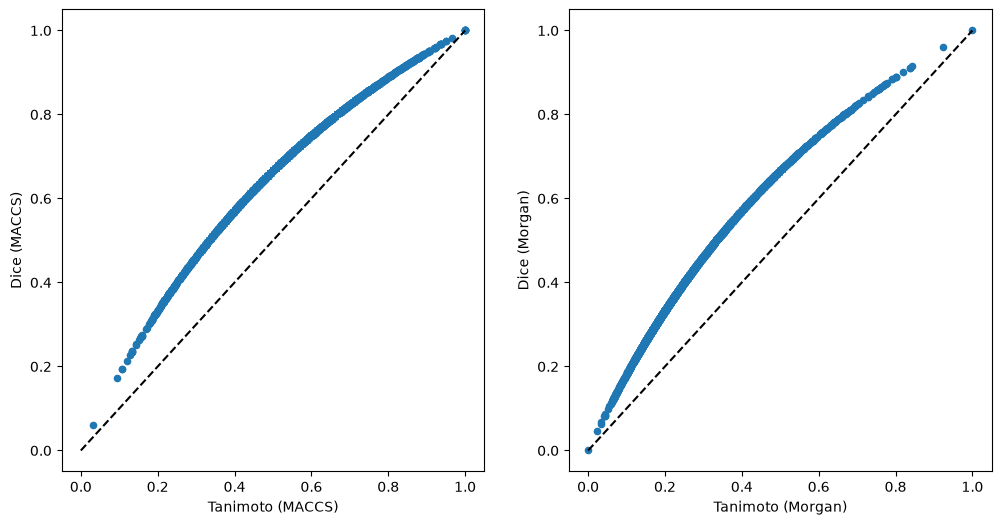

In [39]:
fig, axes = plt.subplots(figsize=(12, 6), nrows=1, ncols=2)

egfr_df.plot("tanimoto_maccs", "dice_maccs", kind="scatter", ax=axes[0])
axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_xlabel("Tanimoto (MACCS)")
axes[0].set_ylabel("Dice (MACCS)")

egfr_df.plot("tanimoto_morgan", "dice_morgan", kind="scatter", ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--")
axes[1].set_xlabel("Tanimoto (Morgan)")
axes[1].set_ylabel("Dice (Morgan)")

fig;

> NOTE: Similarity distributions are important to interpret similarity values, e.g. a value of 0.6 needs to be evaluated differently for MACCS or Morgan fingerprints, as well as Tanimoto or Dice similarities.

### Visualize most similar molecules
Visually inspect the structure of Gefitinib in comparison to the most similar molecules in ranking, including the information about their bioactivity.

,molecule_chembl_id,smiles,pIC50,ROMol,tanimoto_maccs,tanimoto_morgan,dice_maccs,dice_morgan
2663,CHEMBL939,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1,6.288193,,1.000000,1.000000,1.000000,1.000000
892,CHEMBL14699,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCN1CCOCC1,8.000000,,1.000000,0.923913,1.000000,0.960452
1766,CHEMBL299672,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCCC1,7.148742,,0.919355,0.843750,0.957983,0.915254

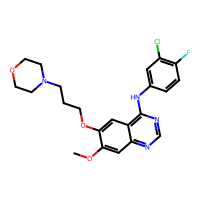
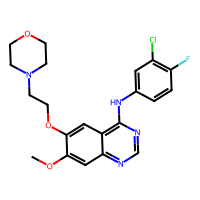
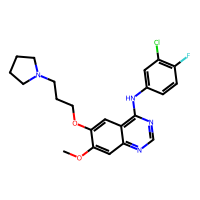

In [40]:
# Sort the DataFrame by Tanimoto similarity of the Morgan fingerprints and show the top 3 molecules.
egfr_df.sort_values(["tanimoto_morgan"], ascending=False).head(3)

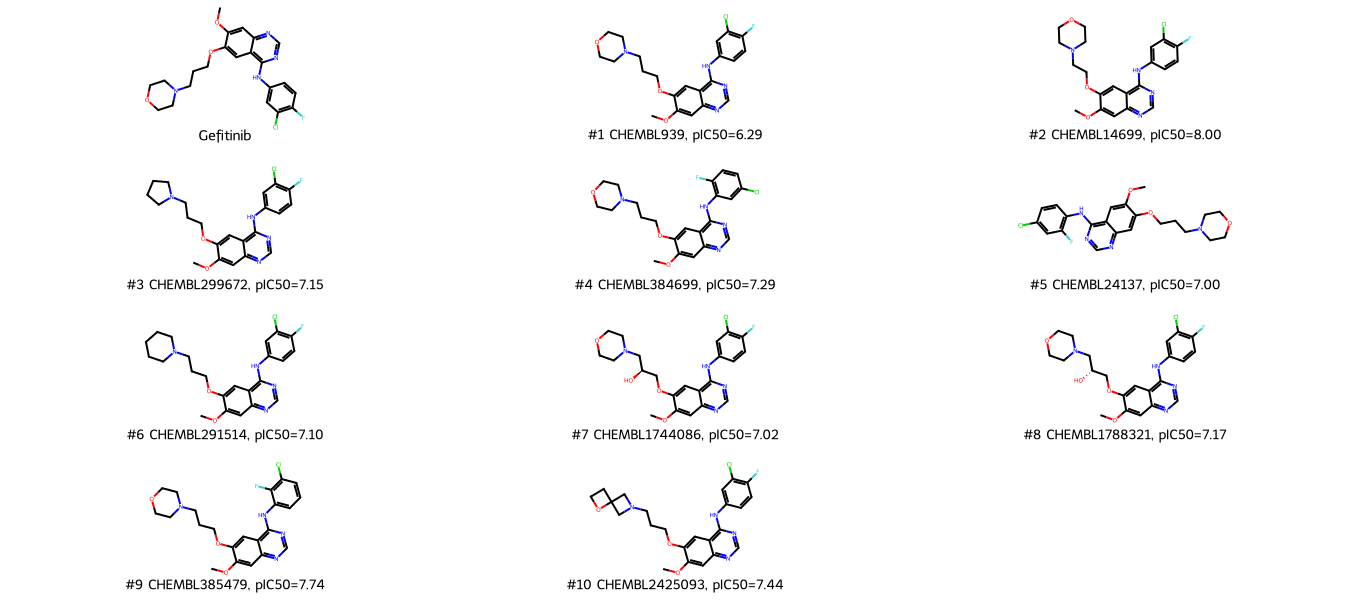

In [41]:
# Show the query (Gefitinib) and its most similar molecules alongside the molecule bioactivity.
top_n_molecules = 10
top_molecules = egfr_df.sort_values(["tanimoto_morgan"], ascending=False).reset_index()
top_molecules = top_molecules[:top_n_molecules]
legends = [
    f"#{index+1} {molecule['molecule_chembl_id']}, pIC50={molecule['pIC50']:.2f}"
    for index, molecule in top_molecules.iterrows()
]
Chem.Draw.MolsToGridImage(
    mols=[query] + top_molecules["ROMol"].tolist(),
    legends=(["Gefitinib"] + legends),
    molsPerRow=3,
    subImgSize=(450, 150),
)

The top ranked molecules for Gefitinib are Gefitinib entries (rank 1 and 2) in our dataset, followed by alterations of Gefitinib, e.g. different benzole substitution patterns. Note: ChEMBL contains the complete structure-activity relationship analysis for Gefitinib (being a well-studied molecule), therefore it is not surprising to have that many Gefitinib-like molecules in our dataset.

Check how well the similarity search is able to distinguish between active and inactive molecules based on the dataset. Therefore, we use the bioactivity values, which we collected from ChEMBL for each molecule (bioactivity against EGFR).

**Generate enrichment plots**
To validate our virtual screening and see the ratio of detected active molecules, we generate an enrichment plot.

**Enrichment plots show:**

- the ratio of top-ranked molecules (x-axis) from the whole dataset vs.

- the ratio of active molecules (y-axis) from the whole dataset.

- compare the Tanimoto similarity for MACCS and Morgan fingerprints.

In order to decide whether we treat a molecule as active or inactive, we apply the commonly used pIC50 cutoff value of 6.3. Although there are several suggestions ranging from an pIC50 cutoff values of 5 to 7 in the literature or even to define an exclusion range, we think this cutoff is reasonable.

,molecule_chembl_id,smiles,pIC50,ROMol,tanimoto_maccs,tanimoto_morgan,dice_maccs,dice_morgan
0,CHEMBL63786,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,,0.409836,0.324786,0.581395,0.490323
1,CHEMBL35820,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849,,0.666667,0.445455,0.800000,0.616352

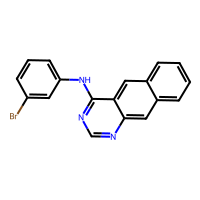
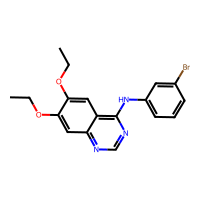

In [43]:
egfr_df.head(2)

In [45]:
def get_enrichment_data(molecules: pd.DataFrame, similarity_measure: str, pic50_cutoff: float) -> pd.DataFrame :
    """
    Calculates x and y values for enrichment plot:
        x - % ranked dataset
        y - % true actives identified

    Parameters
    ----------
    molecules : pandas.DataFrame
        Molecules with similarity values to a query molecule.
    similarity_measure : str
        Column name which will be used to sort the DataFrame．
    pic50_cutoff : float
        pIC50 cutoff value used to discriminate active and inactive molecules.

    Returns
    -------
    pandas.DataFrame
        Enrichment data: Percentage of ranked dataset by similarity vs. percentage of identified true actives.
    """

    # Get number of molecules in data set
    molecules_all = len(molecules)

    # Get number of active molecules in data set
    actives_all = sum(molecules["pIC50"] >= pic50_cutoff)

    # Initialize a list that will hold the counter for actives and molecules while iterating through our dataset
    actives_counter_list = []

    # Initialize counter for actives
    actives_counter = 0

    # Note: Data must be ranked for enrichment plots:
    # Sort molecules by selected similarity measure
    molecules.sort_values([similarity_measure], ascending=False, inplace=True)

    # Iterate over the ranked dataset and check each molecule if active (by checking bioactivity)
    for value in molecules["pIC50"]:
        if value >= pic50_cutoff:
            actives_counter += 1
        actives_counter_list.append(actives_counter)

    # Transform number of molecules into % ranked dataset
    molecules_percentage_list = [i / molecules_all for i in range(1, molecules_all + 1)]

    # Transform number of actives into % true actives identified
    actives_percentage_list = [i / actives_all for i in actives_counter_list]

    # Generate DataFrame with x and y values as well as label
    enrichment = pd.DataFrame(
        {
            "% ranked dataset": molecules_percentage_list,
            "% true actives identified": actives_percentage_list,
        }
    )

    return enrichment

In [46]:
# Set the pIC50 cutoff used to discriminate active and inactive molecules…
pic50_cutoff = 6.3

# Get the enrichment for MACCS and Morgan fingerprints (using the Tanimoto similarity).

similarity_measures = ["tanimoto_maccs", "tanimoto_morgan"]
enrichment_data = {
    similarity_measure: get_enrichment_data(egfr_df, similarity_measure, pic50_cutoff)
    for similarity_measure in similarity_measures
}

In [47]:
enrichment_data["tanimoto_maccs"].head(2)

,% ranked dataset,% true actives identified
0,0.000215,0.000377
1,0.000429,0.000377


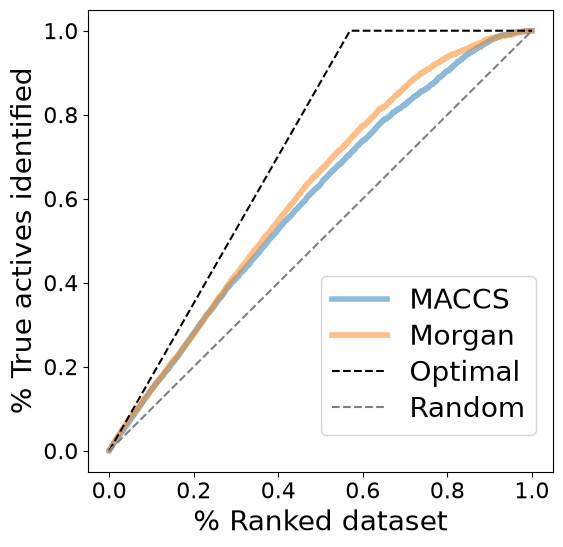

In [48]:
fig, ax = plt.subplots(figsize=(6, 6))

fontsize = 20

# Plot enrichment data
for similarity_measure, enrichment in enrichment_data.items():
    ax = enrichment.plot(
        ax=ax,
        x="% ranked dataset",
        y="% true actives identified",
        label=similarity_measure,
        alpha=0.5,
        linewidth=4,
    )
ax.set_ylabel("% True actives identified", size=fontsize)
ax.set_xlabel("% Ranked dataset", size=fontsize)

# Plot optimal curve: Ratio of actives in dataset
ratio_actives = sum(egfr_df["pIC50"] >= pic50_cutoff) / len(egfr_df)
ax.plot(
    [0, ratio_actives, 1],
    [0, 1, 1],
    label="Optimal curve",
    color="black",
    linestyle="--",
)

# Plot random curve
ax.plot([0, 1], [0, 1], label="Random curve", color="grey", linestyle="--")

plt.tick_params(labelsize=16)
plt.legend(
    labels=["MACCS", "Morgan", "Optimal", "Random"],
    loc=(0.5, 0.08),
    fontsize=fontsize,
    labelspacing=0.3,
)

# Save plot -- use bbox_inches to include text boxes
plt.savefig(
    DATA_DIR / "enrichment_plot.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

plt.show()

The enrichment plots show a slightly better performance for fingerprint comparison based on Morgan fingerprints than based on MACCS fingerprints.

Calculate enrichment factors¶
The (experimental) enrichment factor (EF) is used to access a methods success by a single number rather than a plot. The idea is to determine the percentage of active molecules in the top x% (e.g. 5%) of ranked molecules, as defined by the following helper function.

In [51]:
def calculate_enrichment_factor(enrichment, ranked_dataset_percentage_cutoff):
    """
    Get the experimental enrichment factor for a given percentage of the ranked dataset.

    Parameters
    ----------
    enrichment : pd.DataFrame
        Enrichment data: Percentage of ranked dataset by similarity vs. percentage of
        identified true actives.
    ranked_dataset_percentage_cutoff : float or int
        Percentage of ranked dataset to be included in enrichment factor calculation.

    Returns
    -------
    float
        Experimental enrichment factor.
    """

    # Keep only molecules that meet the cutoff
    enrichment = enrichment[
        enrichment["% ranked dataset"] <= ranked_dataset_percentage_cutoff / 100
        ]
    # Get highest percentage of actives and the corresponding percentage of actives
    highest_enrichment = enrichment.iloc[-1]
    enrichment_factor = round(100 * float(highest_enrichment["% true actives identified"]), 1)
    return enrichment_factor


# This helper function calculates the random enrichment of active molecules in the top x% of ranked molecules (random enrichment factor).
def calculate_enrichment_factor_random(ranked_dataset_percentage_cutoff):
    """
    Get the random enrichment factor for a given percentage of the ranked dataset.

    Parameters
    ----------
    ranked_dataset_percentage_cutoff : float or int
        Percentage of ranked dataset to be included in enrichment factor calculation.

    Returns
    -------
    float
        Random enrichment factor.
    """

    enrichment_factor_random = round(float(ranked_dataset_percentage_cutoff), 1)
    return enrichment_factor_random



    #this helper function calculates the optimal enrichment of active molecules in the top x% of ranked molecules (optimal enrichment factor). 
    # The random and optimal enrichment factors are needed to judge how good the experimental enrichment factor for a method is.
    def calculate_enrichment_factor_optimal(molecules, ranked_dataset_percentage_cutoff, pic50_cutoff):
        """
        Get the optimal random enrichment factor for a given percentage of the ranked dataset.

        Parameters
        ----------
        molecules : pandas.DataFrame
            the DataFrame with all the molecules and pIC50.
        ranked_dataset_percentage_cutoff : float or int
            Percentage of ranked dataset to be included in enrichment factor calculation.
        activity_cutoff: float
            pIC50 cutoff value used to discriminate active and inactive molecules

        Returns
        -------
        float
            Optimal enrichment factor.
        """

        ratio = sum(molecules["pIC50"] >= pic50_cutoff) / len(molecules) * 100
        if ranked_dataset_percentage_cutoff <= ratio:
            enrichment_factor_optimal = round(100 / ratio * ranked_dataset_percentage_cutoff, 1)
        else:
            enrichment_factor_optimal = 100.0
        return enrichment_factor_optimal

Calculate the experimental enrichment factor (EF) for 5% of ranked dataset…